## Imports

In [1]:

import os, sys
from pathlib import Path
from PIL import Image
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import warnings
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.nn.utils import clip_grad_norm_

from tqdm.notebook import tqdm

import random

import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support

from typing import Tuple, Dict, List

import math
import warnings
from torchvision import transforms
from torchvision.models import shufflenet_v2_x0_5, ShuffleNet_V2_X0_5_Weights



## visualisation code

In [2]:
# Enable inline plotting for Jupyter
%matplotlib inline

# Set publication-quality style
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.dpi'] = 100  # Lower for notebook display, saved figures will be 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['legend.fontsize'] = 9
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9

class TrainingLogger:
    """Logger to track training metrics epoch-by-epoch"""
    def __init__(self):
        self.history = {
            'epoch': [],
            'train_loss': [],
            'val_loss': [],
            'train_acc_species': [],
            'val_acc_species': [],
            'train_acc_health': [],
            'val_acc_health': [],
            'train_acc_both': [],
            'val_acc_both': [],
            'lr': []
        }
    
    def log_epoch(self, epoch, train_stats, val_stats, lr):
        """Log metrics for one epoch"""
        self.history['epoch'].append(epoch)
        self.history['train_loss'].append(train_stats['loss'])
        self.history['val_loss'].append(val_stats['loss'])
        self.history['train_acc_species'].append(train_stats['acc_species'])
        self.history['val_acc_species'].append(val_stats['acc_species'])
        self.history['train_acc_health'].append(train_stats['acc_health'])
        self.history['val_acc_health'].append(val_stats['acc_health'])
        self.history['train_acc_both'].append(train_stats['acc_both'])
        self.history['val_acc_both'].append(val_stats['acc_both'])
        self.history['lr'].append(lr)
    
    def plot_convergence(self, save_path='training_convergence.png', model_name='Model', show=True):
        """
        Create publication-quality convergence plots
        
        Args:
            save_path: Path to save the figure
            model_name: Name of the model for the title
            show: Whether to display the plot in notebook (default: True)
        """
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        fig.suptitle(f'{model_name} Training Convergence', fontsize=14, fontweight='bold', y=0.995)
        
        epochs = self.history['epoch']
        
        # Plot 1: Training and Validation Loss
        ax1 = axes[0, 0]
        ax1.plot(epochs, self.history['train_loss'], 'o-', label='Train Loss', 
                linewidth=2, markersize=4, color='#2E86AB', alpha=0.8)
        ax1.plot(epochs, self.history['val_loss'], 's-', label='Val Loss', 
                linewidth=2, markersize=4, color='#A23B72', alpha=0.8)
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Loss')
        ax1.set_title('(a) Multi-task Loss', fontweight='bold', loc='left')
        ax1.legend(framealpha=0.9)
        ax1.grid(True, alpha=0.3)
        
        # Plot 2: Species Accuracy
        ax2 = axes[0, 1]
        ax2.plot(epochs, self.history['train_acc_species'], 'o-', label='Train Species', 
                linewidth=2, markersize=4, color='#2E86AB', alpha=0.8)
        ax2.plot(epochs, self.history['val_acc_species'], 's-', label='Val Species', 
                linewidth=2, markersize=4, color='#A23B72', alpha=0.8)
        ax2.set_xlabel('Epoch')
        ax2.set_ylabel('Accuracy')
        ax2.set_title('(b) Species Classification', fontweight='bold', loc='left')
        ax2.set_ylim([0, 1.05])
        ax2.legend(framealpha=0.9)
        ax2.grid(True, alpha=0.3)
        
        # Plot 3: Disease Accuracy
        ax3 = axes[1, 0]
        ax3.plot(epochs, self.history['train_acc_health'], 'o-', label='Train Disease', 
                linewidth=2, markersize=4, color='#2E86AB', alpha=0.8)
        ax3.plot(epochs, self.history['val_acc_health'], 's-', label='Val Disease', 
                linewidth=2, markersize=4, color='#A23B72', alpha=0.8)
        ax3.set_xlabel('Epoch')
        ax3.set_ylabel('Accuracy')
        ax3.set_title('(c) Disease Detection', fontweight='bold', loc='left')
        ax3.set_ylim([0, 1.05])
        ax3.legend(framealpha=0.9)
        ax3.grid(True, alpha=0.3)
        
        # Plot 4: Joint Accuracy (Both Correct)
        ax4 = axes[1, 1]
        ax4.plot(epochs, self.history['train_acc_both'], 'o-', label='Train Both', 
                linewidth=2, markersize=4, color='#2E86AB', alpha=0.8)
        ax4.plot(epochs, self.history['val_acc_both'], 's-', label='Val Both', 
                linewidth=2, markersize=4, color='#A23B72', alpha=0.8)
        
        # Mark best validation epoch
        best_epoch_idx = np.argmax(self.history['val_acc_both'])
        best_epoch = epochs[best_epoch_idx]
        best_val_both = self.history['val_acc_both'][best_epoch_idx]
        ax4.axvline(x=best_epoch, color='red', linestyle='--', 
                   linewidth=1.5, alpha=0.6, label=f'Best (Epoch {best_epoch})')
        ax4.plot(best_epoch, best_val_both, 'r*', markersize=15, 
                markeredgecolor='darkred', markeredgewidth=1.5)
        
        ax4.set_xlabel('Epoch')
        ax4.set_ylabel('Accuracy')
        ax4.set_title('(d) Joint Accuracy (Primary Metric)', fontweight='bold', loc='left')
        ax4.set_ylim([0, 1.05])
        ax4.legend(framealpha=0.9)
        ax4.grid(True, alpha=0.3)
        
        # Add annotation for best performance
        ax4.annotate(f'{best_val_both:.3f}', 
                    xy=(best_epoch, best_val_both),
                    xytext=(10, -15), textcoords='offset points',
                    bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.7),
                    arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0', color='red'),
                    fontsize=9, fontweight='bold')
        
        plt.tight_layout()
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        print(f"✓ Convergence plot saved to: {save_path}")
        
        if show:
            plt.show()
        else:
            plt.close()
    
    def plot_learning_rate(self, save_path='learning_rate_schedule.png', show=True):
        """Plot learning rate schedule"""
        fig, ax = plt.subplots(figsize=(10, 4))
        
        epochs = self.history['epoch']
        ax.plot(epochs, self.history['lr'], 'o-', linewidth=2, 
               markersize=5, color='#F18F01', label='Learning Rate')
        
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Learning Rate')
        ax.set_title('Learning Rate Schedule (Cosine Annealing)', fontweight='bold')
        ax.legend(framealpha=0.9)
        ax.grid(True, alpha=0.3)
        ax.set_yscale('log')
        
        plt.tight_layout()
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        print(f"✓ Learning rate plot saved to: {save_path}")
        
        if show:
            plt.show()
        else:
            plt.close()
    
    def plot_comparison(self, other_loggers, labels, save_path='model_comparison.png', show=True):
        """
        Compare multiple models on the same plot
        
        Args:
            other_loggers: List of other TrainingLogger instances
            labels: List of model names
            save_path: Path to save comparison figure
            show: Whether to display the plot in notebook
        """
        all_loggers = [self] + other_loggers
        
        fig, axes = plt.subplots(1, 2, figsize=(16, 5))
        fig.suptitle('Multi-Model Performance Comparison', fontsize=14, fontweight='bold')
        
        colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#6A994E', '#BC4B51', '#8B5A3C']
        
        # Plot 1: Validation Loss Comparison
        ax1 = axes[0]
        for i, (logger, label) in enumerate(zip(all_loggers, labels)):
            ax1.plot(logger.history['epoch'], logger.history['val_loss'], 
                    'o-', label=label, linewidth=2, markersize=4, 
                    color=colors[i % len(colors)], alpha=0.8)
        
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Validation Loss')
        ax1.set_title('(a) Validation Loss', fontweight='bold', loc='left')
        ax1.legend(framealpha=0.9, loc='best')
        ax1.grid(True, alpha=0.3)
        
        # Plot 2: Joint Accuracy Comparison
        ax2 = axes[1]
        for i, (logger, label) in enumerate(zip(all_loggers, labels)):
            ax2.plot(logger.history['epoch'], logger.history['val_acc_both'], 
                    'o-', label=label, linewidth=2, markersize=4, 
                    color=colors[i % len(colors)], alpha=0.8)
        
        ax2.set_xlabel('Epoch')
        ax2.set_ylabel('Validation Joint Accuracy')
        ax2.set_title('(b) Joint Accuracy (Both Correct)', fontweight='bold', loc='left')
        ax2.set_ylim([0, 1.05])
        ax2.legend(framealpha=0.9, loc='best')
        ax2.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        print(f"✓ Comparison plot saved to: {save_path}")
        
        if show:
            plt.show()
        else:
            plt.close()
    
    def save_history(self, save_path='training_history.csv'):
        """Save training history to CSV"""
        df = pd.DataFrame(self.history)
        df.to_csv(save_path, index=False)
        print(f"✓ Training history saved to: {save_path}")

print("✓ TrainingLogger class loaded successfully!")

✓ TrainingLogger class loaded successfully!


## training code

In [3]:

# -------------------------------
# Config
# -------------------------------
DATA_ROOT = Path("/workspace/Dataset_split")
IMG_SIZE  = 224
BATCH_SIZE = 32
NUM_WORKERS = 0
EPOCHS = 50
LR = 1e-4
WEIGHT_DECAY = 5e-4
DROPOUT = 0.3
NUM_SPECIES = 3
NUM_HEALTH = 2
PRETRAINED = False
GRADIENT_CLIP = 1.0
PATIENCE = 5
SEED = 42
LOSS_WEIGHT_HEALTH = 1.0
USE_AMP = True
device = torch.device("cuda" if torch.cuda.is_available() else
                      "mps" if hasattr(torch.backends, "mps") and torch.backends.mps.is_available()
                      else "cpu")
print("Device:", device)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# -------------------------------
# Label maps
# -------------------------------
SPECIES_MAP = {"Guava":0, "Mango":1, "Papaya":2}
HEALTH_MAP  = {"Healthy":0, "Anthracnose":1}

def parse_joint_label(folder_name: str) -> Tuple[int,int]:
    name = folder_name.strip()
    if "_" not in name:
        raise ValueError(f"Folder name not joint label: {name}")
    sp, he = name.split("_", 1)
    sp_id = SPECIES_MAP[sp]
    he_id = HEALTH_MAP[he]
    return sp_id, he_id

# -------------------------------
# Dataset
# -------------------------------
class JointLeafDataset(Dataset):
    def __init__(self, split_root: Path, transform=None):
        self.split_root = Path(split_root)
        self.samples: List[Tuple[str, int, int]] = []
        self.transform = transform
        for folder in sorted([d for d in self.split_root.iterdir() if d.is_dir()]):
            sp_id, he_id = parse_joint_label(folder.name)
            for p in folder.rglob("*"):
                if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp"}:
                    self.samples.append((str(p), sp_id, he_id))
        if len(self.samples) == 0:
            raise RuntimeError(f"No images found under {split_root}")
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        path, sp_id, he_id = self.samples[idx]
       
        try:
            img = Image.open(path).convert('RGB')
        except Exception as e:
            print(f"Error loading image {path}: {e}")
            img = Image.new('RGB', (IMG_SIZE, IMG_SIZE))
       
        if self.transform is not None:
            img = self.transform(img)
       
        return img, torch.tensor(sp_id, dtype=torch.long), torch.tensor(he_id, dtype=torch.long)

# -------------------------------
# Transforms (offline augmentation already applied)
# -------------------------------
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE), interpolation=transforms.InterpolationMode.BILINEAR),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE), interpolation=transforms.InterpolationMode.BILINEAR),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

# -------------------------------
# Datasets & Loaders
# -------------------------------
print("Loading datasets...")
train_ds = JointLeafDataset(DATA_ROOT / "train", transform=train_tf)
val_ds   = JointLeafDataset(DATA_ROOT / "val",   transform=eval_tf)
test_ds  = JointLeafDataset(DATA_ROOT / "test",  transform=eval_tf)
print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

# Test loading one sample
print("\nTesting sample loading...")
try:
    sample_img, sample_sp, sample_he = train_ds[0]
    print(f"✓ Sample loaded successfully: shape={sample_img.shape}, species={sample_sp}, health={sample_he}")
except Exception as e:
    print(f"✗ Failed to load sample: {e}")
    raise

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=(device.type=="cuda"))
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=(device.type=="cuda"))
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=(device.type=="cuda"))

# Test DataLoader
print("\nTesting DataLoader...")
try:
    for i, (imgs, sp, he) in enumerate(train_loader):
        print(f"✓ Batch {i}: imgs {imgs.shape}, species {sp.shape}, health {he.shape}")
        if i >= 2:
            break
    print("✓ DataLoader test passed!\n")
except Exception as e:
    print(f"✗ DataLoader failed: {e}")
    import traceback
    traceback.print_exc()
    raise



Device: cuda
Loading datasets...
Train: 6000 | Val: 749 | Test: 768

Testing sample loading...
✓ Sample loaded successfully: shape=torch.Size([3, 224, 224]), species=0, health=1

Testing DataLoader...
✓ Batch 0: imgs torch.Size([32, 3, 224, 224]), species torch.Size([32]), health torch.Size([32])
✓ Batch 1: imgs torch.Size([32, 3, 224, 224]), species torch.Size([32]), health torch.Size([32])
✓ Batch 2: imgs torch.Size([32, 3, 224, 224]), species torch.Size([32]), health torch.Size([32])
✓ DataLoader test passed!



## Model Definition

In [4]:
# -------------------------------
# Multi-Task ShuffleNetV2 Model
# -------------------------------
class MultiTaskShuffleNetV2(nn.Module):
    """
    Multi-task model using ShuffleNetV2 backbone.
    Two output heads: species classification and health classification.
    """
    def __init__(self, num_species=NUM_SPECIES, num_health=NUM_HEALTH, pretrained=PRETRAINED, dropout=DROPOUT):
        super(MultiTaskShuffleNetV2, self).__init__()
        
        # Load pretrained ShuffleNetV2 x0.5 (1.36M params)
        if pretrained:
            weights = ShuffleNet_V2_X0_5_Weights.DEFAULT
            self.backbone = shufflenet_v2_x0_5(weights=weights)
        else:
            self.backbone = shufflenet_v2_x0_5(weights=None)
        
        # Get feature dimension from the classifier
        in_features = self.backbone.fc.in_features
        
        # Remove original classifier
        self.backbone.fc = nn.Identity()
        
        # Species classification head
        self.species_head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_features, num_species)
        )
        
        # Health classification head
        self.health_head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_features, num_health)
        )
    
    def forward(self, x):
        # Extract features
        features = self.backbone(x)
        
        # Get predictions from both heads
        species_out = self.species_head(features)
        health_out = self.health_head(features)
        
        return species_out, health_out

# Instantiate model
print("Creating MultiTaskShuffleNetV2 model...")
model = MultiTaskShuffleNetV2(
    num_species=NUM_SPECIES,
    num_health=NUM_HEALTH,
    pretrained=PRETRAINED,
    dropout=DROPOUT
).to(device)

print(f"Model moved to {device}")
print(f"\nModel architecture:")
print(model)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# -------------------------------
# Optimizer, Scheduler, Loss
# -------------------------------
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=LR/100)

criterion_species = nn.CrossEntropyLoss()
criterion_health  = nn.CrossEntropyLoss()

# AMP scaler for mixed precision
scaler = torch.cuda.amp.GradScaler() if USE_AMP and device.type=="cuda" else None

# -------------------------------
# Training/Evaluation Function with Gradient Clipping
# -------------------------------
def run_epoch(loader, model, optimizer=None, train=False, epoch=0):
    if train:
        model.train()
    else:
        model.eval()
    
    running_loss = 0.0
    correct_species = 0
    correct_health = 0
    correct_both = 0
    total = 0
    
    pbar = tqdm(loader, desc=f"{'Train' if train else 'Eval'} Epoch {epoch+1}")
    
    for imgs, y_species, y_health in pbar:
        imgs = imgs.to(device, non_blocking=True)
        y_species = y_species.to(device, non_blocking=True)
        y_health = y_health.to(device, non_blocking=True)
        
        batch_size = imgs.size(0)
        
        if train and optimizer:
            optimizer.zero_grad()
            
            if USE_AMP and scaler:
                # Mixed precision training with gradient clipping
                with torch.cuda.amp.autocast():
                    logits_species, logits_health = model(imgs)
                    loss_species = criterion_species(logits_species, y_species)
                    loss_health  = criterion_health(logits_health, y_health)
                    loss = loss_species + LOSS_WEIGHT_HEALTH * loss_health
                
                scaler.scale(loss).backward()
                
                # Gradient clipping
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), GRADIENT_CLIP)
                
                scaler.step(optimizer)
                scaler.update()
            else:
                # Standard training with gradient clipping
                logits_species, logits_health = model(imgs)
                loss_species = criterion_species(logits_species, y_species)
                loss_health  = criterion_health(logits_health, y_health)
                loss = loss_species + LOSS_WEIGHT_HEALTH * loss_health
                
                loss.backward()
                
                # Gradient clipping
                torch.nn.utils.clip_grad_norm_(model.parameters(), GRADIENT_CLIP)
                
                optimizer.step()
        else:
            # Evaluation mode
            with torch.no_grad():
                logits_species, logits_health = model(imgs)
                loss_species = criterion_species(logits_species, y_species)
                loss_health  = criterion_health(logits_health, y_health)
                loss = loss_species + LOSS_WEIGHT_HEALTH * loss_health
        
        # Calculate accuracies
        preds_species = logits_species.argmax(dim=1)
        preds_health  = logits_health.argmax(dim=1)
        
        correct_species += (preds_species == y_species).sum().item()
        correct_health  += (preds_health == y_health).sum().item()
        both_correct = (preds_species == y_species) & (preds_health == y_health)
        correct_both += both_correct.sum().item()
        
        running_loss += loss.item() * batch_size
        total += batch_size
        
        # Update progress bar
        pbar.set_postfix({
            'loss': f'{running_loss/total:.3f}',
            'sp_acc': f'{correct_species/total:.3f}',
            'he_acc': f'{correct_health/total:.3f}',
            'both_acc': f'{correct_both/total:.3f}'
        })
    
    avg_loss = running_loss / total
    acc_species = correct_species / total
    acc_health = correct_health / total
    acc_both = correct_both / total
    
    return {
        "loss": avg_loss,
        "acc_species": acc_species,
        "acc_health": acc_health,
        "acc_both": acc_both
    }

print("✓ Training function with gradient clipping loaded!")



Creating MultiTaskShuffleNetV2 model...
Model moved to cuda

Model architecture:
MultiTaskShuffleNetV2(
  (backbone): ShuffleNetV2(
    (conv1): Sequential(
      (0): Conv2d(3, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (stage2): Sequential(
      (0): InvertedResidual(
        (branch1): Sequential(
          (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=24, bias=False)
          (1): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): Conv2d(24, 24, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (3): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (4): ReLU(inplace=True)
        )
        (branch2): Sequential(
      

/tmp/ipykernel_5720/1863144491.py:76: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if USE_AMP and device.type=="cuda" else None


## Training loop

In [5]:
# -------------------------------
# Training Loop
# -------------------------------

# Storage for history
history = {
    "train_loss": [], "val_loss": [],
    "train_acc_species": [], "val_acc_species": [],
    "train_acc_health": [], "val_acc_health": [],
    "train_acc_both": [], "val_acc_both": []
}

best_val_both = 0.0
best_epoch = 0
epochs_without_improvement = 0

print("="*80)
print("STARTING TRAINING")
print("="*80)

for epoch in range(EPOCHS):
    print(f"\n{'='*80}")
    print(f"Epoch {epoch+1}/{EPOCHS} | LR: {optimizer.param_groups[0]['lr']:.2e}")
    print(f"{'='*80}")
    
    # Train
    print("Training...")
    train_stats = run_epoch(train_loader, model, optimizer, train=True, epoch=epoch)
    
    # Validate
    print("Validating...")
    val_stats = run_epoch(val_loader, model, optimizer=None, train=False, epoch=epoch)
    
    # Update scheduler
    scheduler.step()
    
    # Store history
    history["train_loss"].append(train_stats["loss"])
    history["val_loss"].append(val_stats["loss"])
    history["train_acc_species"].append(train_stats["acc_species"])
    history["val_acc_species"].append(val_stats["acc_species"])
    history["train_acc_health"].append(train_stats["acc_health"])
    history["val_acc_health"].append(val_stats["acc_health"])
    history["train_acc_both"].append(train_stats["acc_both"])
    history["val_acc_both"].append(val_stats["acc_both"])
    
    # Print summary
    print(f"\n{'EPOCH SUMMARY':^80}")
    print("-"*80)
    print(f"  Train - Loss: {train_stats['loss']:.4f} | Species: {train_stats['acc_species']:.3f} | "
          f"Health: {train_stats['acc_health']:.3f} | Both: {train_stats['acc_both']:.3f}")
    print(f"  Val   - Loss: {val_stats['loss']:.4f} | Species: {val_stats['acc_species']:.3f} | "
          f"Health: {val_stats['acc_health']:.3f} | Both: {val_stats['acc_both']:.3f}")
    
    # Save best model and check for improvement
    if val_stats["acc_both"] > best_val_both:
        best_val_both = val_stats["acc_both"]
        best_epoch = epoch
        epochs_without_improvement = 0
        torch.save({
            "model": model.state_dict(),
            "optimizer": optimizer.state_dict(),
            "epoch": epoch,
            "val_both": best_val_both
        }, "best_multitask_ShuffleNetV2.pt")
        print(f"  ★ New best model saved! Val Both Acc: {best_val_both:.4f}")
    else:
        epochs_without_improvement += 1
        print(f"  No improvement. Epochs without improvement: {epochs_without_improvement}/{PATIENCE}")
    
    # Early stopping
    if epochs_without_improvement >= PATIENCE:
        print(f"\n{'⚠ EARLY STOPPING TRIGGERED':^80}")
        print(f"No improvement for {PATIENCE} epochs. Stopping training.")
        break
    
    print(f"{'='*80}\n")

print("\n" + "="*80)
print("TRAINING COMPLETE")
print("="*80)
print(f"Best epoch: {best_epoch+1} with val_both={best_val_both:.4f}")
print(f"Total epochs trained: {epoch+1}/{EPOCHS}")


STARTING TRAINING

Epoch 1/50 | LR: 1.00e-04
Training...


Train Epoch 1:   0%|          | 0/188 [00:00<?, ?it/s]

/tmp/ipykernel_5720/1863144491.py:107: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Validating...


Eval Epoch 1:   0%|          | 0/24 [00:00<?, ?it/s]

...


                                 EPOCH SUMMARY                                  
--------------------------------------------------------------------------------
  Train - Loss: 0.3810 | Species: 0.949 | Health: 0.894 | Both: 0.852
  Val   - Loss: 0.5948 | Species: 0.951 | Health: 0.821 | Both: 0.784
  No improvement. Epochs without improvement: 4/5


Epoch 32/50 | LR: 3.23e-05
Training...


Train Epoch 32:   0%|          | 0/188 [00:00<?, ?it/s]

Validating...


Eval Epoch 32:   0%|          | 0/24 [00:00<?, ?it/s]


                                 EPOCH SUMMARY                                  
--------------------------------------------------------------------------------
  Train - Loss: 0.3715 | Species: 0.954 | Health: 0.900 | Both: 0.863
  Val   - Loss: 0.6002 | Species: 0.949 | Health: 0.830 | Both: 0.798
  No improvement. Epochs without improvement: 5/5

                           ⚠ EARLY STOPPING TRIGGERED                           
No improvement for 5 epochs. Stopping training.

TRAINING COMPLETE
Best epoch: 27 with val_both=0.8011
Total epochs trained: 32/50


In [6]:
# -------------------------------
# Test the best model
# -------------------------------

MODEL_NAME = "best_multitask_ShuffleNetV2.pt"

print("Testing best model on test set...")
checkpoint = torch.load(MODEL_NAME, map_location=device)
model.load_state_dict(checkpoint["model"])
print(f"Loaded best model from epoch {checkpoint['epoch']+1} with val_both={checkpoint['val_both']:.3f}")

# Running the test phase
test_stats = run_epoch(test_loader, model, optimizer=None, train=False)
print(f"\n{'TEST SET RESULTS':^80}")
print("-"*80)
print(f"  Loss: {test_stats['loss']:.4f}")
print(f"  Species Accuracy: {test_stats['acc_species']:.4f} ({test_stats['acc_species']*100:.2f}%)")
print(f"  Health Accuracy:  {test_stats['acc_health']:.4f} ({test_stats['acc_health']*100:.2f}%)")
print(f"  Both Correct:     {test_stats['acc_both']:.4f} ({test_stats['acc_both']*100:.2f}%)")
print("-"*80 + "\n")

# Save final model
torch.save({"model": model.state_dict(),
            "epoch": EPOCHS - 1,
            "test_stats": test_stats,
            "spec": {"species_map": SPECIES_MAP, "health_map": HEALTH_MAP}},
           "final_multitask_ShuffleNetV2.pt")
print("✓ Saved final model as 'final_multitask_ShuffleNetV2.pt'\n")


# -------------------------------
# Final test phase (Additional)
# -------------------------------
print("="*80)
print("Running Final Test")
print("="*80 + "\n")

with torch.no_grad():
    final_test_stats = run_epoch(test_loader, model, optimizer=None, train=False, epoch=EPOCHS-1)

# Display Final Test Results
print("\n" + "="*80)
print("Final Test Results:")
print(f"  loss: {final_test_stats['loss']:.4f} | species: {final_test_stats['acc_species']:.3f} | health: {final_test_stats['acc_health']:.3f} | both: {final_test_stats['acc_both']:.3f}")
print("="*80)

# -------------------------------
# Summary & Visualizations
# -------------------------------
print(f"\nTraining completed for {MODEL_NAME}")
print(f"Best validation both accuracy: {best_val_both:.3f}")

# Visualizations saved:
print(f"  - convergence_{MODEL_NAME.lower().replace('-', '_')}.png")
print(f"  - lr_schedule_{MODEL_NAME.lower().replace('-', '_')}.png")
print(f"  - history_{MODEL_NAME.lower().replace('-', '_')}.csv")
print("="*80)


Testing best model on test set...
Loaded best model from epoch 27 with val_both=0.801


Eval Epoch 1:   0%|          | 0/24 [00:00<?, ?it/s]


                                TEST SET RESULTS                                
--------------------------------------------------------------------------------
  Loss: 0.5368
  Species Accuracy: 0.9466 (94.66%)
  Health Accuracy:  0.8516 (85.16%)
  Both Correct:     0.8112 (81.12%)
--------------------------------------------------------------------------------

✓ Saved final model as 'final_multitask_ShuffleNetV2.pt'

Running Final Test



Eval Epoch 50:   0%|          | 0/24 [00:00<?, ?it/s]


Final Test Results:
  loss: 0.5368 | species: 0.947 | health: 0.852 | both: 0.811

Training completed for best_multitask_ShuffleNetV2.pt
Best validation both accuracy: 0.801
  - convergence_best_multitask_shufflenetv2.pt.png
  - lr_schedule_best_multitask_shufflenetv2.pt.png
  - history_best_multitask_shufflenetv2.pt.csv


## Plot saving

In [7]:
# -------------------------------
# Save Individual Training Plots
# -------------------------------
print("\nGenerating individual training plots...")

epochs_range = range(1, len(history['train_loss']) + 1)

# 1. Training Loss
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(epochs_range, history['train_loss'], 'b-o', label='Train Loss', linewidth=2, markersize=6)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('Training Loss Over Epochs', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plot_train_loss.png', dpi=150, bbox_inches='tight')
print("✓ Saved plot_train_loss.png")
plt.close()

# 2. Validation Loss
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(epochs_range, history['val_loss'], 'r-o', label='Validation Loss', linewidth=2, markersize=6)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('Validation Loss Over Epochs', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plot_val_loss.png', dpi=150, bbox_inches='tight')
print("✓ Saved plot_val_loss.png")
plt.close()

# 3. Train vs Val Loss Comparison
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(epochs_range, history['train_loss'], 'b-o', label='Train Loss', linewidth=2, markersize=6)
ax.plot(epochs_range, history['val_loss'], 'r-o', label='Val Loss', linewidth=2, markersize=6)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('Training vs Validation Loss', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plot_loss_comparison.png', dpi=150, bbox_inches='tight')
print("✓ Saved plot_loss_comparison.png")
plt.close()

# 4. Species Accuracy
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(epochs_range, history['train_acc_species'], 'b-o', label='Train Species Acc', linewidth=2, markersize=6)
ax.plot(epochs_range, history['val_acc_species'], 'r-o', label='Val Species Acc', linewidth=2, markersize=6)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Species Classification Accuracy', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1.05])
plt.tight_layout()
plt.savefig('plot_species_accuracy.png', dpi=150, bbox_inches='tight')
print("✓ Saved plot_species_accuracy.png")
plt.close()

# 5. Health Accuracy
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(epochs_range, history['train_acc_health'], 'b-o', label='Train Health Acc', linewidth=2, markersize=6)
ax.plot(epochs_range, history['val_acc_health'], 'r-o', label='Val Health Acc', linewidth=2, markersize=6)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Health/Disease Classification Accuracy', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1.05])
plt.tight_layout()
plt.savefig('plot_health_accuracy.png', dpi=150, bbox_inches='tight')
print("✓ Saved plot_health_accuracy.png")
plt.close()

# 6. Joint (Both) Accuracy
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(epochs_range, history['train_acc_both'], 'b-o', label='Train Both Acc', linewidth=2, markersize=6)
ax.plot(epochs_range, history['val_acc_both'], 'r-o', label='Val Both Acc', linewidth=2, markersize=6)
ax.axhline(y=best_val_both, color='g', linestyle='--', linewidth=2, label=f'Best Val Both: {best_val_both:.3f}')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Joint Classification Accuracy (Both Tasks Correct)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1.05])
plt.tight_layout()
plt.savefig('plot_joint_accuracy.png', dpi=150, bbox_inches='tight')
print("✓ Saved plot_joint_accuracy.png")
plt.close()

# 7. All Accuracies Together (Optional comprehensive view)
fig, ax = plt.subplots(figsize=(12, 7))
ax.plot(epochs_range, history['train_acc_species'], 'b-o', label='Train Species', linewidth=2, markersize=5)
ax.plot(epochs_range, history['val_acc_species'], 'b--s', label='Val Species', linewidth=2, markersize=5)
ax.plot(epochs_range, history['train_acc_health'], 'g-o', label='Train Health', linewidth=2, markersize=5)
ax.plot(epochs_range, history['val_acc_health'], 'g--s', label='Val Health', linewidth=2, markersize=5)
ax.plot(epochs_range, history['train_acc_both'], 'r-o', label='Train Both', linewidth=2, markersize=5)
ax.plot(epochs_range, history['val_acc_both'], 'r--s', label='Val Both', linewidth=2, markersize=5)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('All Metrics Over Training', fontsize=14, fontweight='bold')
ax.legend(fontsize=10, ncol=2)
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1.05])
plt.tight_layout()
plt.savefig('plot_all_metrics.png', dpi=150, bbox_inches='tight')
print("✓ Saved plot_all_metrics.png")
plt.close()

print("\n" + "="*80)
print("All training plots saved:")
print("  - plot_train_loss.png")
print("  - plot_val_loss.png")
print("  - plot_loss_comparison.png")
print("  - plot_species_accuracy.png")
print("  - plot_health_accuracy.png")
print("  - plot_joint_accuracy.png")
print("  - plot_all_metrics.png")
print("="*80 + "\n")


Generating individual training plots...
✓ Saved plot_train_loss.png
✓ Saved plot_val_loss.png
✓ Saved plot_loss_comparison.png
✓ Saved plot_species_accuracy.png
✓ Saved plot_health_accuracy.png
✓ Saved plot_joint_accuracy.png
✓ Saved plot_all_metrics.png

All training plots saved:
  - plot_train_loss.png
  - plot_val_loss.png
  - plot_loss_comparison.png
  - plot_species_accuracy.png
  - plot_health_accuracy.png
  - plot_joint_accuracy.png
  - plot_all_metrics.png



## metrics

Loaded best model from epoch 27 with val_both=0.801
Running comprehensive test evaluation...

COMPREHENSIVE TEST RESULTS

                               OVERALL ACCURACIES                               
--------------------------------------------------------------------------------
  Species Classification:  0.9466 (94.66%)
  Health Classification:   0.8516 (85.16%)
  Both Correct (Joint):    0.8112 (81.12%)

                         SPECIES CLASSIFICATION REPORT                          
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

       Guava     0.9481    0.8933    0.9199       225
       Mango     0.9405    0.9576    0.9489       330
      Papaya     0.9545    0.9859    0.9700       213

    accuracy                         0.9466       768
   macro avg     0.9477    0.9456    0.9463       768
weighted avg     0.9466    0.9466    0.9463       768


                      HEALTH/DISEASE CLASS

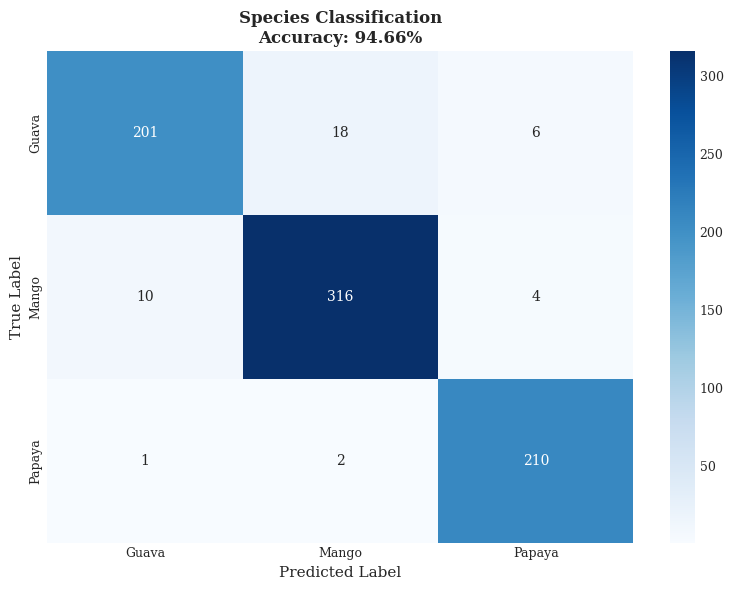

Saved health confusion matrix to 'confusion_matrix_health.png'


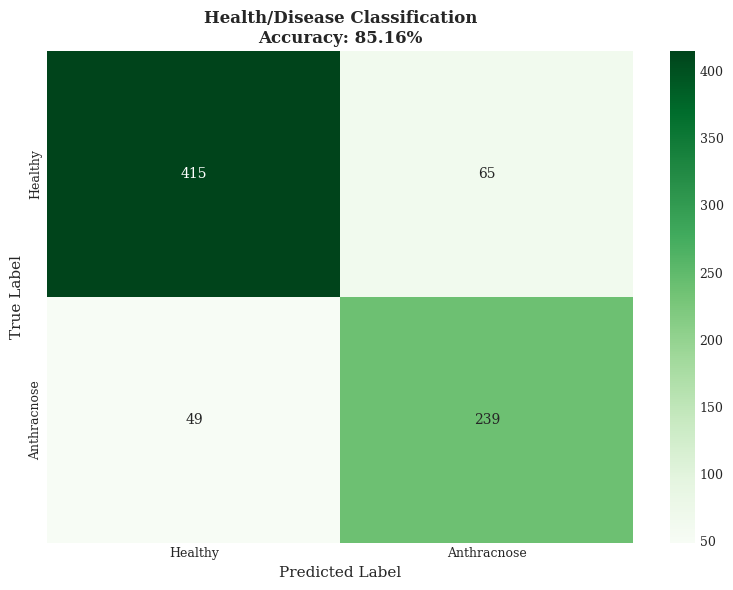

Saved joint accuracy heatmap to 'joint_accuracy_heatmap.png'


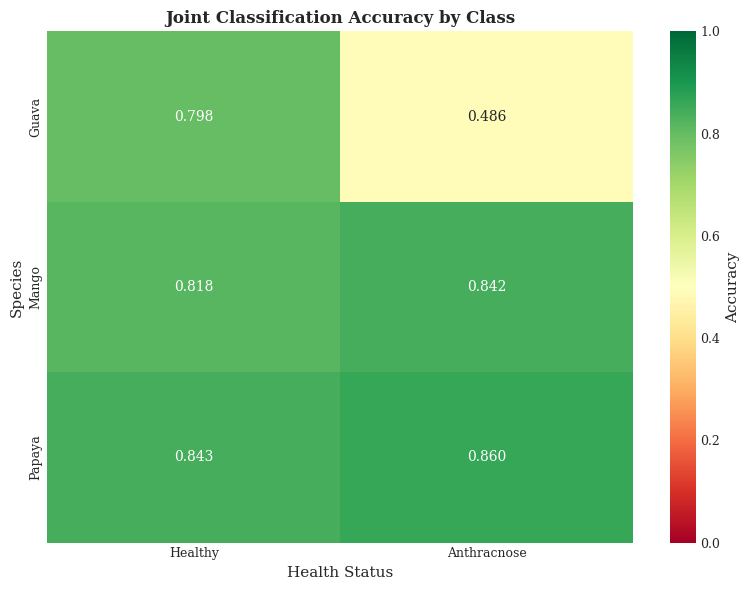


Testing complete! Generated visualizations:
  - confusion_matrices.png
  - sample_predictions.png
  - joint_accuracy_heatmap.png



In [9]:

# -------------------------------
# Comprehensive Testing Function
# -------------------------------
def comprehensive_test(model, test_loader, device, species_map, health_map):
    """
    Perform comprehensive testing with metrics and visualizations
    """
    model.eval()
    
    # Storage for predictions and ground truth
    all_species_preds = []
    all_species_true = []
    all_health_preds = []
    all_health_true = []
    all_both_correct = []
    
    # For visualization: store some sample predictions
    sample_images = []
    sample_predictions = []
    sample_ground_truth = []
    max_samples = 20  # Number of samples to visualize
    
    print("Running comprehensive test evaluation...")
    
    with torch.no_grad():
        for batch_idx, (imgs, y_species, y_health) in enumerate(test_loader):
            imgs = imgs.to(device, non_blocking=True)
            y_species = y_species.to(device, non_blocking=True)
            y_health = y_health.to(device, non_blocking=True)
            
            # Get predictions
            logits_species, logits_health = model(imgs)
            preds_species = logits_species.argmax(dim=1)
            preds_health = logits_health.argmax(dim=1)
            
            # Store predictions and ground truth
            all_species_preds.extend(preds_species.cpu().numpy())
            all_species_true.extend(y_species.cpu().numpy())
            all_health_preds.extend(preds_health.cpu().numpy())
            all_health_true.extend(y_health.cpu().numpy())
            
            # Check if both predictions are correct
            both_correct = ((preds_species == y_species) & (preds_health == y_health)).cpu().numpy()
            all_both_correct.extend(both_correct)
            
            # Store samples for visualization
            if len(sample_images) < max_samples:
                for i in range(min(imgs.size(0), max_samples - len(sample_images))):
                    sample_images.append(imgs[i].cpu())
                    sample_predictions.append({
                        'species': preds_species[i].item(),
                        'health': preds_health[i].item()
                    })
                    sample_ground_truth.append({
                        'species': y_species[i].item(),
                        'health': y_health[i].item()
                    })
    
    # Convert to numpy arrays
    all_species_preds = np.array(all_species_preds)
    all_species_true = np.array(all_species_true)
    all_health_preds = np.array(all_health_preds)
    all_health_true = np.array(all_health_true)
    all_both_correct = np.array(all_both_correct)
    
    # Reverse mapping for labels
    species_labels = {v: k.capitalize() for k, v in species_map.items()}
    health_labels = {v: k.capitalize() for k, v in health_map.items()}
    
    # -------------------------------
    # Print Metrics
    # -------------------------------
    print("\n" + "="*80)
    print("COMPREHENSIVE TEST RESULTS")
    print("="*80)
    
    # Overall accuracies
    species_acc = accuracy_score(all_species_true, all_species_preds)
    health_acc = accuracy_score(all_health_true, all_health_preds)
    both_acc = all_both_correct.mean()
    
    print(f"\n{'OVERALL ACCURACIES':^80}")
    print("-"*80)
    print(f"  Species Classification:  {species_acc:.4f} ({species_acc*100:.2f}%)")
    print(f"  Health Classification:   {health_acc:.4f} ({health_acc*100:.2f}%)")
    print(f"  Both Correct (Joint):    {both_acc:.4f} ({both_acc*100:.2f}%)")
    
    # Species Classification Report
    print(f"\n{'SPECIES CLASSIFICATION REPORT':^80}")
    print("-"*80)
    print(classification_report(
        all_species_true, 
        all_species_preds,
        target_names=[species_labels[i] for i in sorted(species_labels.keys())],
        digits=4
    ))
    
    # Health Classification Report
    print(f"\n{'HEALTH/DISEASE CLASSIFICATION REPORT':^80}")
    print("-"*80)
    print(classification_report(
        all_health_true, 
        all_health_preds,
        target_names=[health_labels[i] for i in sorted(health_labels.keys())],
        digits=4
    ))
    
    # Per-class joint accuracy
    print(f"\n{'PER-CLASS JOINT ACCURACY':^80}")
    print("-"*80)
    for sp_id in sorted(species_labels.keys()):
        for he_id in sorted(health_labels.keys()):
            # Find samples of this joint class
            mask = (all_species_true == sp_id) & (all_health_true == he_id)
            if mask.sum() > 0:
                joint_acc = all_both_correct[mask].mean()
                count = mask.sum()
                sp_name = species_labels[sp_id]
                he_name = health_labels[he_id]
                print(f"  {sp_name:8s} + {he_name:12s}: {joint_acc:.4f} ({joint_acc*100:.2f}%) [{count:4d} samples]")
    
    # -------------------------------
    # Visualizations
    # -------------------------------
    
    # 1. Confusion Matrices - Individual Images

    # Species confusion matrix
    fig, ax = plt.subplots(figsize=(8, 6))
    cm_species = confusion_matrix(all_species_true, all_species_preds)
    sns.heatmap(cm_species, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=[species_labels[i] for i in sorted(species_labels.keys())],
                yticklabels=[species_labels[i] for i in sorted(species_labels.keys())])
    ax.set_title(f'Species Classification\nAccuracy: {species_acc:.2%}', fontsize=12, fontweight='bold')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

    plt.tight_layout()
    plt.savefig('confusion_matrix_species.png', dpi=150, bbox_inches='tight')
    print(f"Saved species confusion matrix to 'confusion_matrix_species.png'")
    plt.show()
    plt.close()


    # Health confusion matrix
    fig, ax = plt.subplots(figsize=(8, 6))
    cm_health = confusion_matrix(all_health_true, all_health_preds)
    sns.heatmap(cm_health, annot=True, fmt='d', cmap='Greens', ax=ax,
                xticklabels=[health_labels[i] for i in sorted(health_labels.keys())],
                yticklabels=[health_labels[i] for i in sorted(health_labels.keys())])
    ax.set_title(f'Health/Disease Classification\nAccuracy: {health_acc:.2%}', fontsize=12, fontweight='bold')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

    plt.tight_layout()
    plt.savefig('confusion_matrix_health.png', dpi=150, bbox_inches='tight')
    print(f"Saved health confusion matrix to 'confusion_matrix_health.png'")
    plt.show()
    plt.close()
   
    
    
    
    # 3. Joint Accuracy Heatmap
    fig, ax = plt.subplots(figsize=(8, 6))
    joint_acc_matrix = np.zeros((len(species_labels), len(health_labels)))
    
    for sp_id in sorted(species_labels.keys()):
        for he_id in sorted(health_labels.keys()):
            mask = (all_species_true == sp_id) & (all_health_true == he_id)
            if mask.sum() > 0:
                joint_acc_matrix[sp_id, he_id] = all_both_correct[mask].mean()
    
    sns.heatmap(joint_acc_matrix, annot=True, fmt='.3f', cmap='RdYlGn', 
                xticklabels=[health_labels[i] for i in sorted(health_labels.keys())],
                yticklabels=[species_labels[i] for i in sorted(species_labels.keys())],
                vmin=0, vmax=1, ax=ax, cbar_kws={'label': 'Accuracy'})
    ax.set_title('Joint Classification Accuracy by Class', fontsize=12, fontweight='bold')
    ax.set_ylabel('Species')
    ax.set_xlabel('Health Status')
    
    plt.tight_layout()
    plt.savefig('joint_accuracy_heatmap.png', dpi=150, bbox_inches='tight')
    print(f"Saved joint accuracy heatmap to 'joint_accuracy_heatmap.png'")
    plt.show()
    plt.close()
    
    print("\n" + "="*80)
    print("Testing complete! Generated visualizations:")
    print("  - confusion_matrices.png")
    print("  - sample_predictions.png")
    print("  - joint_accuracy_heatmap.png")
    print("="*80 + "\n")
    
    return {
        'species_accuracy': species_acc,
        'health_accuracy': health_acc,
        'joint_accuracy': both_acc,
        'species_preds': all_species_preds,
        'species_true': all_species_true,
        'health_preds': all_health_preds,
        'health_true': all_health_true
    }


# -------------------------------
# Usage: Run after training
# -------------------------------

# Load the best model
checkpoint = torch.load("best_multitask_ShuffleNetV2.pt", map_location=device)
model.load_state_dict(checkpoint["model"])
print(f"Loaded best model from epoch {checkpoint['epoch']+1} with val_both={checkpoint['val_both']:.3f}")

# Run comprehensive testing
test_results = comprehensive_test(
    model=model,
    test_loader=test_loader,
    device=device,
    species_map=SPECIES_MAP,
    health_map=HEALTH_MAP
)

## 10 sample visualisation from 3 class

Saved sample predictions (30 total: 10 per class) to 'sample_predictions.png'


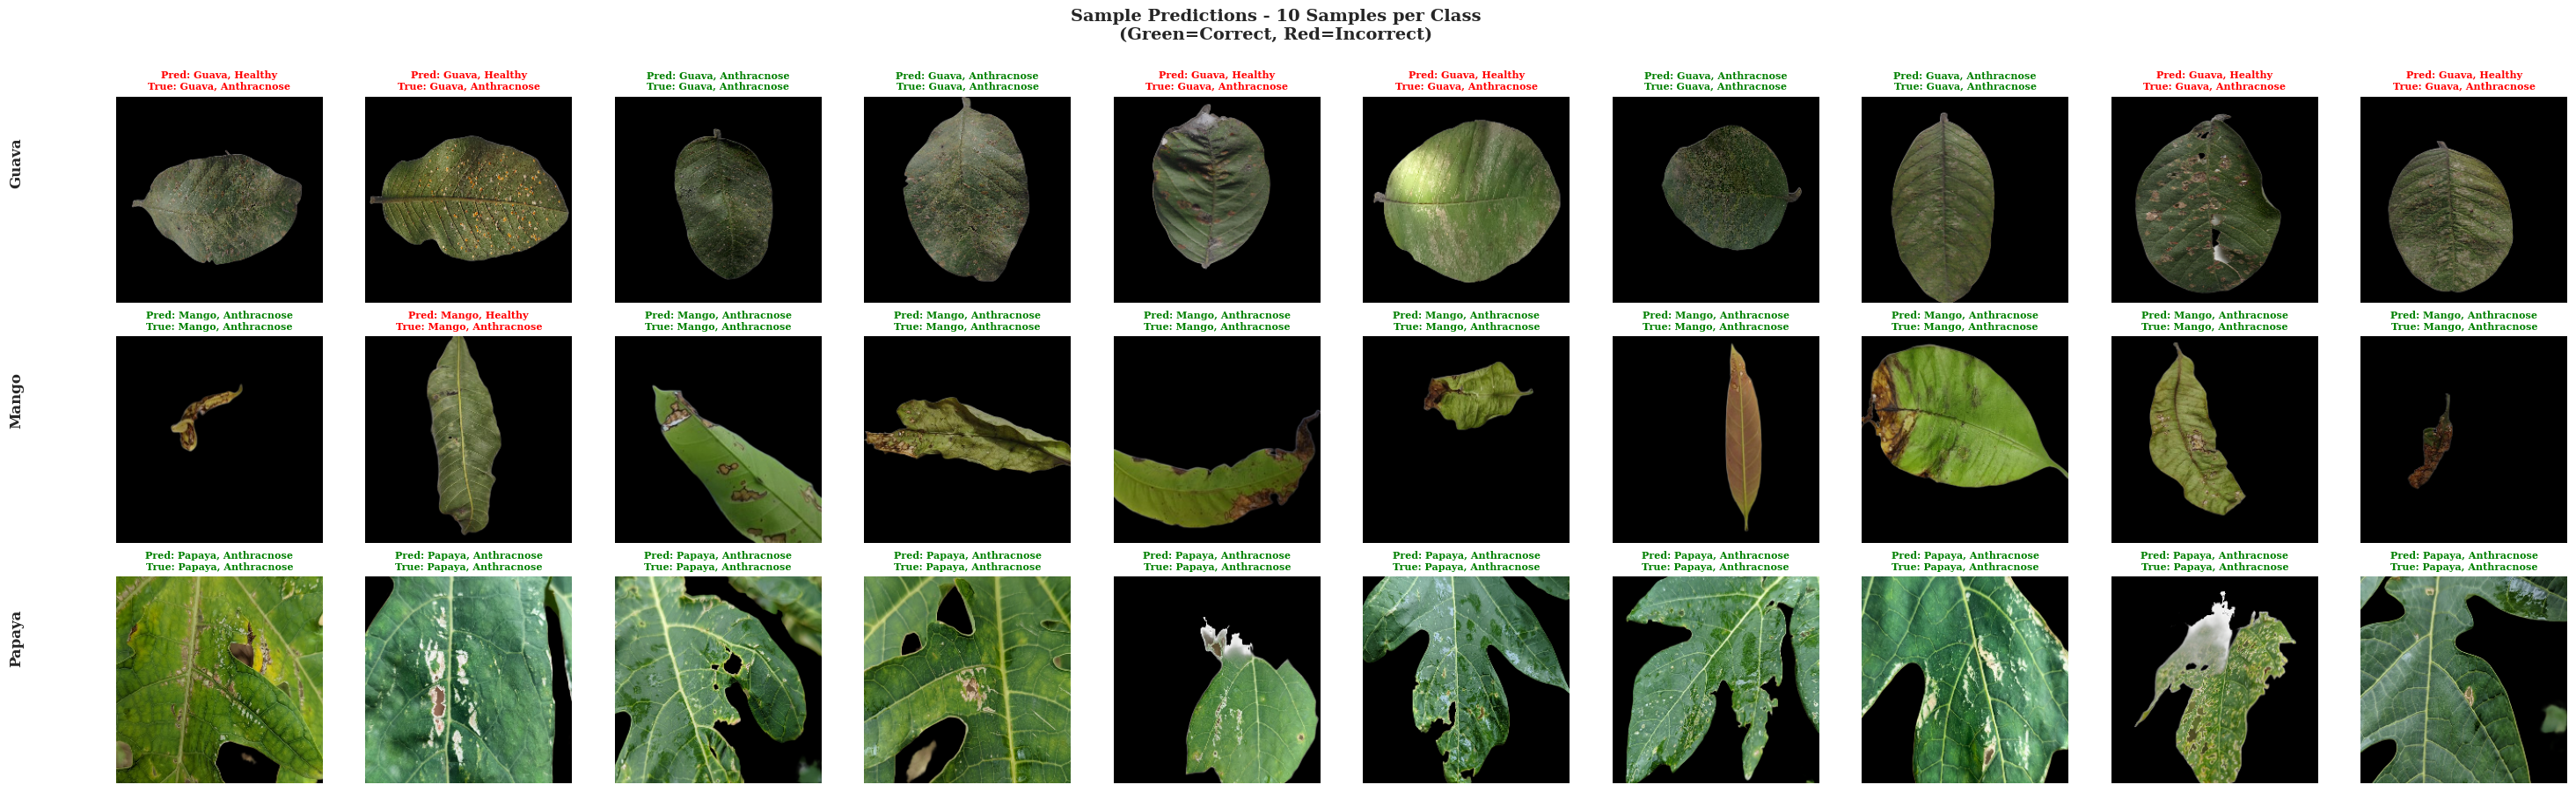

In [10]:
# Load model
# Define your label mappings
species_labels = {
    0: 'Guava',
    1: 'Mango',
    2: 'Papaya'
}

health_labels = {
    0: 'Healthy',
    1: 'Anthracnose',
}
checkpoint = torch.load("best_multitask_ShuffleNetV2.pt")
model.load_state_dict(checkpoint["model"])
model.eval()

# Number of samples to display per class
amount = 10

# Collect samples from validation set
sample_images_by_class = {0: [], 1: [], 2: []}
sample_predictions_by_class = {0: [], 1: [], 2: []}
sample_ground_truth_by_class = {0: [], 1: [], 2: []}

with torch.no_grad():
    for images, species_batch, health_batch in val_loader:
        images = images.to(device)
        
        outputs = model(images)
        species_preds = outputs[0].argmax(1)
        health_preds = outputs[1].argmax(1)
        
        for i in range(len(images)):
            species_class = species_batch[i].item()
            
            if len(sample_images_by_class[species_class]) < amount:
                sample_images_by_class[species_class].append(images[i].cpu())
                sample_predictions_by_class[species_class].append({
                    'species': species_preds[i].item(),
                    'health': health_preds[i].item()
                })
                sample_ground_truth_by_class[species_class].append({
                    'species': species_batch[i].item(),
                    'health': health_batch[i].item()
                })
        
        if all(len(samples) >= amount for samples in sample_images_by_class.values()):
            break

# Visualize
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

fig, axes = plt.subplots(3, amount, figsize=(3*amount, 9))

for row, species_idx in enumerate(sorted(sample_images_by_class.keys())):
    for col in range(amount):
        ax = axes[row, col]
        
        img = sample_images_by_class[species_idx][col]
        pred = sample_predictions_by_class[species_idx][col]
        gt = sample_ground_truth_by_class[species_idx][col]
        
        # Denormalize and display
        img_display = img.numpy().transpose(1, 2, 0)
        img_display = std * img_display + mean
        img_display = np.clip(img_display, 0, 1)
        
        ax.imshow(img_display)
        ax.axis('off')
        
        # Check correctness
        both_correct = (pred['species'] == gt['species']) and (pred['health'] == gt['health'])
        
        # Create title
        pred_sp = species_labels[pred['species']]
        pred_he = health_labels[pred['health']]
        gt_sp = species_labels[gt['species']]
        gt_he = health_labels[gt['health']]
        
        title = f"Pred: {pred_sp}, {pred_he}\nTrue: {gt_sp}, {gt_he}"
        color = 'green' if both_correct else 'red'
        ax.set_title(title, fontsize=8, color=color, fontweight='bold')
    
    # Add species label
    fig.text(0.02, 0.5 + (1 - row) * 0.3, species_labels[species_idx], 
             fontsize=12, fontweight='bold', va='center', rotation=90)

plt.suptitle(f'Sample Predictions - {amount} Samples per Class\n(Green=Correct, Red=Incorrect)', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout(rect=[0.05, 0, 1, 0.99])
plt.savefig('sample_predictions.png', dpi=150, bbox_inches='tight')
print(f"Saved sample predictions ({3*amount} total: {amount} per class) to 'sample_predictions.png'")
plt.show()
plt.close()